In [2]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [16]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from torchvision.transforms import transforms
from project.models import EDMMauMau, EDMSerie
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [17]:
plt.style.use(['science','no-latex', 'nature'])

In [13]:
PATH = os.path.join("..", "checkpoints", "diff", "SpaceInvaders.pt")
DATA = os.path.join("..", "checkpoints", "memory", "SpaceInvaders.pt")
N = 8
SIGMA = 0.25
SAMPLES = 1

In [5]:
device = "cuda:1"

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [7]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [18]:
sample = data[2112].unsqueeze(0)
sample_noisy = sample +  SIGMA * torch.randn_like(sample)

In [ ]:
model_naive = EDMMauMau.from_checkpoint(PATH, device=device, sigma_noise=SIGMA)
model_full = EDMMauMau.from_checkpoint(PATH, device=device, sigma_noise=SIGMA, N=8)

In [ ]:
sample_naive = model_naive.denoise(sample_noisy.to(device))
sample_full = model_full.denoise(sample_noisy.to(device))

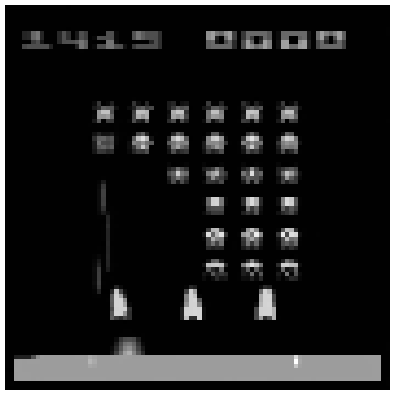

In [26]:
plt.figure(figsize=(5, 5))
plt.imshow(sample_full.squeeze().mean(0).to("cpu"), cmap="grey")
plt.axis("off")
plt.savefig("../results/denoising/y_hat_full.svg")
plt.show()